# STARmap_Wang2018 content analysis

This notebook opens `STARmap_Wang2018three_data_3D_data.h5ad` and inspects the contents of the AnnData object: observations/cells, genes/features, 3D spatial coordinates, Leiden clusters, UMAP embeddings, neighbor graphs, and spatial autocorrelation statistics.

## Setup

Run the install cell if this environment does not already have the single-cell analysis stack available.

In [2]:
# Optional: uncomment and run if dependencies are missing.
# %pip install anndata h5py scipy pandas numpy matplotlib

In [3]:
from pathlib import Path

import anndata as ad
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Load the dataset

In [4]:
NOTEBOOK_DIR = Path.cwd()
DATA_PATH = NOTEBOOK_DIR.parent / "STARmap_Wang2018three_data_3D_data.h5ad"

if not DATA_PATH.exists():
    DATA_PATH = Path("STARmap_Wang2018three_data_3D_data.h5ad").resolve()

assert DATA_PATH.exists(), f"Could not find dataset at {DATA_PATH}"
DATA_PATH

PosixPath('/home/cristina/3DCPath-datasets/STARmap_Wang2018three_data_3D_data.h5ad')

In [5]:
adata = ad.read_h5ad(DATA_PATH)
adata

AnnData object with n_obs × n_vars = 32845 × 28
    obs: 'x', 'y', 'z', 'n_counts', 'leiden'
    uns: 'leiden', 'leiden_colors', 'moranI', 'neighbors', 'spatial_neighbors', 'umap'
    obsm: 'X_umap', 'spatial'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances'

## H5AD layout

This gives a compact view of the raw HDF5 groups and datasets in the file.

In [6]:
def h5ad_inventory(path):
    rows = []

    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            rows.append({
                "path": f"/{name}",
                "kind": "dataset",
                "shape": obj.shape,
                "dtype": str(obj.dtype),
            })
        elif isinstance(obj, h5py.Group):
            rows.append({
                "path": f"/{name}",
                "kind": "group",
                "shape": "",
                "dtype": "",
            })

    with h5py.File(path, "r") as handle:
        handle.visititems(visitor)

    return pd.DataFrame(rows).sort_values("path").reset_index(drop=True)

inventory = h5ad_inventory(DATA_PATH)
inventory

,path,kind,shape,dtype
0,/X,group,,
1,/X/data,dataset,"(907987,)",float32
2,/X/indices,dataset,"(907987,)",int32
3,/X/indptr,dataset,"(32846,)",int32
4,/layers,group,,
...,...,...,...,...
64,/uns/umap/params/b,dataset,(),float64
65,/var,group,,
66,/var/_index,dataset,"(28,)",object
67,/varm,group,,


## Object summary

In [7]:
summary = pd.Series({
    "n_observations": adata.n_obs,
    "n_features": adata.n_vars,
    "X_type": type(adata.X).__name__,
    "X_shape": adata.X.shape,
    "obs_columns": list(adata.obs.columns),
    "var_columns": list(adata.var.columns),
    "obsm_keys": list(adata.obsm.keys()),
    "obsp_keys": list(adata.obsp.keys()),
    "uns_keys": list(adata.uns.keys()),
})
summary

n_observations                                                32845
n_features                                                       28
X_type                                                   csr_matrix
X_shape                                                 (32845, 28)
obs_columns                             [x, y, z, n_counts, leiden]
var_columns                                                      []
obsm_keys                                         [X_umap, spatial]
obsp_keys         [connectivities, distances, spatial_connectivi...
uns_keys          [leiden, leiden_colors, moranI, neighbors, spa...
dtype: object

In [8]:
print("Features / genes:")
display(pd.DataFrame({"gene": adata.var_names}).head(50))

print("Observation metadata preview:")
display(adata.obs.head())

Features / genes:


,gene
0,Slc17a7
1,Mgp
2,Gad1
3,Nov
4,Rasgrf2
5,Rorb
6,Cux2
7,Plcxd2
8,Sulf2
9,Ctgf


Observation metadata preview:


,x,y,z,n_counts,leiden
cell_8,11,609,15,464905.0,8
cell_11,12,937,8,202874.0,10
cell_12,14,1144,6,218283.0,7
cell_13,15,535,7,375481.0,8
cell_14,19,954,6,195569.0,11


## Cell metadata and coordinates

In [9]:
coordinate_columns = [col for col in ["x", "y", "z"] if col in adata.obs]

metadata_summary = {}
if "n_counts" in adata.obs:
    metadata_summary["n_counts"] = adata.obs["n_counts"].describe()
if coordinate_columns:
    metadata_summary["coordinates"] = adata.obs[coordinate_columns].describe()

for name, table in metadata_summary.items():
    print(name)
    display(table)

n_counts


count    3.284500e+04
mean     1.917586e+05
std      1.796151e+05
min      6.143000e+03
25%      7.758600e+04
50%      1.306190e+05
75%      2.284490e+05
max      5.089288e+06
Name: n_counts, dtype: float64

coordinates


,x,y,z
count,32845.000000,32845.000000,32845.000000
mean,801.966235,798.213518,51.585934
std,429.416509,429.692055,25.246746
min,11.000000,11.000000,6.000000
25%,440.000000,435.000000,30.000000
50%,820.000000,808.000000,52.000000
75%,1156.000000,1168.000000,74.000000
max,1810.000000,1525.000000,94.000000


,leiden,n_cells
0,0,3262
1,1,2910
2,2,2842
3,3,2709
4,4,2517
5,5,2331
6,6,2324
7,7,2043
8,8,1694
9,9,1691


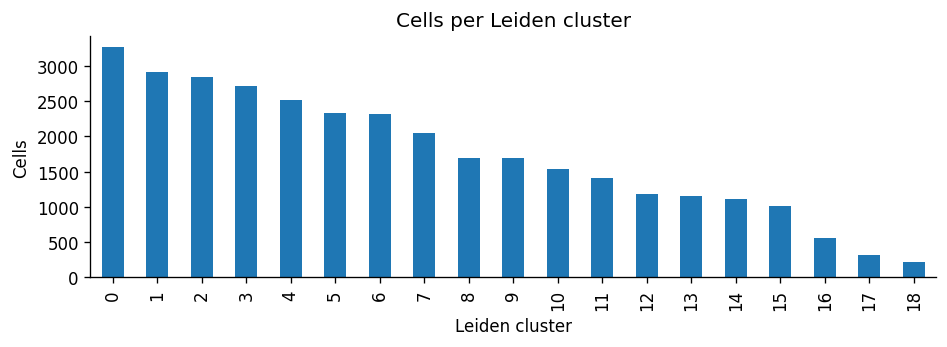

In [10]:
if "leiden" in adata.obs:
    cluster_counts = (
        adata.obs["leiden"]
        .value_counts()
        .rename_axis("leiden")
        .reset_index(name="n_cells")
        .sort_values("leiden")
    )
    display(cluster_counts)

    ax = cluster_counts.plot.bar(x="leiden", y="n_cells", legend=False, figsize=(8, 3))
    ax.set_xlabel("Leiden cluster")
    ax.set_ylabel("Cells")
    ax.set_title("Cells per Leiden cluster")
    plt.tight_layout()

## Spatial distribution

`obs[['x', 'y', 'z']]` stores the 3D coordinates. `obsm['spatial']` stores a 2D spatial embedding.

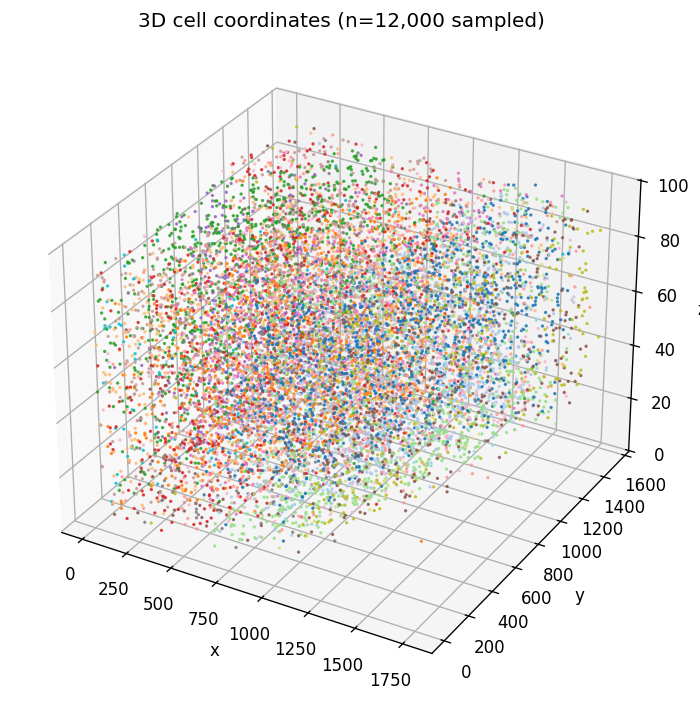

In [11]:
if set(["x", "y", "z"]).issubset(adata.obs.columns):
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(projection="3d")

    sample_size = min(adata.n_obs, 12000)
    rng = np.random.default_rng(7)
    sample_idx = rng.choice(adata.n_obs, size=sample_size, replace=False)
    coords = adata.obs.iloc[sample_idx][["x", "y", "z"]]

    if "leiden" in adata.obs:
        colors = adata.obs.iloc[sample_idx]["leiden"].astype("category").cat.codes
        scatter = ax.scatter(coords["x"], coords["y"], coords["z"], c=colors, s=1, cmap="tab20", alpha=0.8)
    else:
        scatter = ax.scatter(coords["x"], coords["y"], coords["z"], s=1, alpha=0.8)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title(f"3D cell coordinates (n={sample_size:,} sampled)")
    plt.tight_layout()

In [ ]:
if "spatial" in adata.obsm:
    spatial = pd.DataFrame(adata.obsm["spatial"], columns=["spatial_1", "spatial_2"], index=adata.obs_names)
    fig, ax = plt.subplots(figsize=(6, 5))
    if "leiden" in adata.obs:
        colors = adata.obs["leiden"].astype("category").cat.codes
        ax.scatter(spatial["spatial_1"], spatial["spatial_2"], c=colors, s=1, cmap="tab20", alpha=0.75)
    else:
        ax.scatter(spatial["spatial_1"], spatial["spatial_2"], s=1, alpha=0.75)
    ax.set_xlabel("spatial_1")
    ax.set_ylabel("spatial_2")
    ax.set_title("2D spatial coordinates")
    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()

## UMAP embedding

In [ ]:
if "X_umap" in adata.obsm:
    umap = pd.DataFrame(adata.obsm["X_umap"], index=adata.obs_names)
    dims = umap.shape[1]
    display(umap.describe())

    fig, ax = plt.subplots(figsize=(6, 5))
    if "leiden" in adata.obs:
        colors = adata.obs["leiden"].astype("category").cat.codes
        ax.scatter(umap.iloc[:, 0], umap.iloc[:, 1], c=colors, s=1, cmap="tab20", alpha=0.75)
    else:
        ax.scatter(umap.iloc[:, 0], umap.iloc[:, 1], s=1, alpha=0.75)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_title(f"UMAP embedding ({dims}D available)")
    plt.tight_layout()

## Gene expression content

In [ ]:
X = adata.X
if sparse.issparse(X):
    gene_totals = np.asarray(X.sum(axis=0)).ravel()
    gene_detected_cells = np.asarray((X > 0).sum(axis=0)).ravel()
    cell_detected_genes = np.asarray((X > 0).sum(axis=1)).ravel()
else:
    gene_totals = X.sum(axis=0)
    gene_detected_cells = (X > 0).sum(axis=0)
    cell_detected_genes = (X > 0).sum(axis=1)

gene_summary = pd.DataFrame({
    "gene": adata.var_names,
    "total_expression": gene_totals,
    "detected_cells": gene_detected_cells,
    "detected_fraction": gene_detected_cells / adata.n_obs,
}).sort_values("total_expression", ascending=False)

display(gene_summary)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
gene_summary.head(20).plot.bar(x="gene", y="total_expression", ax=axes[0], legend=False)
axes[0].set_title("Top genes by total expression")
axes[0].set_xlabel("")
axes[0].set_ylabel("Total expression")

axes[1].hist(cell_detected_genes, bins=30)
axes[1].set_title("Detected genes per cell")
axes[1].set_xlabel("Genes detected")
axes[1].set_ylabel("Cells")
plt.tight_layout()

In [ ]:
if "leiden" in adata.obs:
    expression = pd.DataFrame(
        adata.X.toarray() if sparse.issparse(adata.X) else adata.X,
        index=adata.obs_names,
        columns=adata.var_names,
    )
    expression["leiden"] = adata.obs["leiden"].astype(str).values
    cluster_gene_means = expression.groupby("leiden").mean()
    display(cluster_gene_means)

    fig, ax = plt.subplots(figsize=(10, 5))
    image = ax.imshow(cluster_gene_means.T, aspect="auto", interpolation="nearest", cmap="viridis")
    ax.set_xticks(np.arange(cluster_gene_means.shape[0]))
    ax.set_xticklabels(cluster_gene_means.index, rotation=90)
    ax.set_yticks(np.arange(cluster_gene_means.shape[1]))
    ax.set_yticklabels(cluster_gene_means.columns)
    ax.set_xlabel("Leiden cluster")
    ax.set_ylabel("Gene")
    ax.set_title("Mean expression by cluster")
    fig.colorbar(image, ax=ax, label="Mean expression")
    plt.tight_layout()

## Spatial autocorrelation and graphs

In [ ]:
if "moranI" in adata.uns:
    moran = pd.DataFrame(adata.uns["moranI"])
    display(moran.sort_values("I", ascending=False))

    ax = moran.sort_values("I", ascending=False).plot.bar(x=moran.index.name or "_index", y="I", legend=False, figsize=(8, 3)) if "_index" in moran.columns else moran.sort_values("I", ascending=False)["I"].plot.bar(figsize=(8, 3))
    ax.set_title("Moran's I by gene")
    ax.set_xlabel("Gene")
    ax.set_ylabel("Moran's I")
    plt.tight_layout()

In [ ]:
graph_summary = []
for key, matrix in adata.obsp.items():
    nnz = matrix.nnz if sparse.issparse(matrix) else np.count_nonzero(matrix)
    graph_summary.append({
        "graph": key,
        "shape": matrix.shape,
        "nonzero_entries": nnz,
        "mean_nonzero_per_cell": nnz / matrix.shape[0],
    })

pd.DataFrame(graph_summary)

## Export compact summaries

These CSV files are small derived summaries that can be inspected outside the notebook.

In [ ]:
OUTPUT_DIR = NOTEBOOK_DIR / "outputs" / "STARmap_Wang2018"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

gene_summary.to_csv(OUTPUT_DIR / "gene_expression_summary.csv", index=False)

if "leiden" in adata.obs:
    cluster_counts.to_csv(OUTPUT_DIR / "leiden_cluster_counts.csv", index=False)
    cluster_gene_means.to_csv(OUTPUT_DIR / "cluster_gene_means.csv")

if "moranI" in adata.uns:
    moran.to_csv(OUTPUT_DIR / "moranI_summary.csv")

print(f"Wrote summaries to {OUTPUT_DIR}")